# Kadanoff-Baym Equations with α-Relaxation

**Goal:** Apply α-transform relaxation to the time-dependent non-equilibrium Dyson equation on the Keldysh contour.

The Kadanoff-Baym equations are the non-equilibrium generalisation of the Dyson equation:

$$G^R(t,t') = G_0^R(t,t') + \int dt_1\, G_0^R(t,t_1)\, \Sigma^R(t_1, t')\, G^R(t_1, t')$$

$$G^<(t,t') = \int dt_1 dt_2\, G^R(t,t_1)\, \Sigma^<(t_1,t_2)\, G^A(t_2,t')$$

The propagators split into three Keldysh components:
- **Retarded** $G^R$: causal response
- **Advanced** $G^A = [G^R]^\dagger$: anti-causal
- **Lesser** $G^<$: occupation / distribution

**Key question:** Can α-relaxation stabilize the time-stepping without damping physical signals?

**Predictions from earlier results:**
- The piecewise α(ω) result (α*≈0.5 everywhere) suggests a single global α should suffice
- But each Keldysh component may need a different α (retarded vs lesser have different stability properties)
- The Lyapunov Z₂ symmetry Λ(α) = Λ(−α) should manifest as equivalent stabilization for ±α

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from dask.distributed import Client, as_completed
from petrification.dyson import (
    scalar_dyson_iterate, scalar_dyson_exact,
    scalar_dyson_stability, spectral_dyson_scan,
    quadratic_self_energy, hubbard_atom_self_energy
)

client = Client(n_workers=4, threads_per_worker=1, memory_limit='2GB')
print(client)
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

<Client: 'tcp://127.0.0.1:36605' processes=4 threads=4, memory=7.45 GiB>


## §2. Time-Domain Kadanoff-Baym Solver

Discretize the KB equations on a time grid. The retarded component satisfies a Volterra integral equation that we solve by stepping forward in time. At each step, the self-energy depends on $G$ itself (self-consistency), making this a fixed-point iteration at each time step.

In [2]:
G_CLAMP = 1e3  # max magnitude for Green's functions

def clamp(arr, maxval=G_CLAMP):
    mask = np.abs(arr) > maxval
    arr[mask] *= maxval / np.abs(arr[mask])
    return arr


def kb_retarded_step(G_R, Sigma_R, h0, dt, t_idx, alpha=1.0):
    n = t_idx
    G_R[n, n] = -1j
    for tp in range(n):
        mem = 0.0
        for t1 in range(tp, n):
            w = dt
            if t1 == tp or t1 == n-1:
                w *= 0.5
            mem += w * Sigma_R[n, t1] * G_R[t1, tp]
        G_new = G_R[n-1, tp] - 1j * dt * (h0 * G_R[n-1, tp] + mem)
        if n > 1 and tp < n-1:
            G_R[n, tp] = alpha * G_new + (1 - alpha) * G_R[n-1, tp]
        else:
            G_R[n, tp] = G_new
    clamp(G_R[n, :n+1])
    return G_R


def kb_lesser_step(G_less, G_R, Sigma_less, dt, t_idx, alpha=1.0):
    n = t_idx
    for tp in range(n+1):
        val = 0.0
        for t1 in range(n+1):
            for t2 in range(tp+1):
                w = dt * dt
                if t1 == 0 or t1 == n:
                    w *= 0.5
                if t2 == 0 or t2 == tp:
                    w *= 0.5
                G_A_t2_tp = np.conj(G_R[tp, t2]) if tp >= t2 else np.conj(G_R[t2, tp])
                val += w * G_R[n, t1] * Sigma_less[t1, t2] * G_A_t2_tp
        G_new = val
        if n > 0 and tp < n:
            old = G_less[n-1, tp] if n > 0 else 0.0
            G_less[n, tp] = alpha * G_new + (1 - alpha) * old
        else:
            G_less[n, tp] = G_new
    clamp(G_less[n, :n+1])
    return G_less


def solve_kb_equations(h0, U, beta, n_times, t_max, alpha_R=1.0, alpha_less=1.0):
    dt = t_max / n_times
    times = np.linspace(0, t_max, n_times)
    G_R = np.zeros((n_times, n_times), dtype=complex)
    G_less = np.zeros((n_times, n_times), dtype=complex)
    Sigma_R = np.zeros((n_times, n_times), dtype=complex)
    Sigma_less = np.zeros((n_times, n_times), dtype=complex)
    nf = 1.0 / (np.exp(beta * h0) + 1) if abs(h0) > 1e-15 else 0.5

    for i in range(n_times):
        for j in range(i+1):
            G_R[i, j] = -1j * np.exp(-1j * h0 * (times[i] - times[j]))
            G_less[i, j] = 1j * nf * np.exp(-1j * h0 * (times[i] - times[j]))

    n_sc_iter = 5
    sigma_mix = 0.3   # self-energy under-relaxation
    residuals = []
    for sc_iter in range(n_sc_iter):
        G_R_old = G_R.copy()
        Sigma_R_new = np.zeros_like(Sigma_R)
        Sigma_less_new = np.zeros_like(Sigma_less)
        for i in range(n_times):
            for j in range(i+1):
                Sigma_R_new[i, j] = U**2 * G_R[i, j] * abs(G_less[i, j])**2
                Sigma_less_new[i, j] = U**2 * G_less[i, j] * abs(G_R[i, j])**2
        # Under-relax self-energy
        Sigma_R = sigma_mix * Sigma_R_new + (1 - sigma_mix) * Sigma_R
        Sigma_less = sigma_mix * Sigma_less_new + (1 - sigma_mix) * Sigma_less
        clamp(Sigma_R)
        clamp(Sigma_less)
        for t_idx in range(1, n_times):
            G_R = kb_retarded_step(G_R, Sigma_R, h0, dt, t_idx, alpha=alpha_R)
            G_less = kb_lesser_step(G_less, G_R, Sigma_less, dt, t_idx, alpha=alpha_less)
        res = np.max(np.abs(G_R - G_R_old))
        residuals.append(res)
    return times, G_R, G_less, residuals

print('KB solver defined (with overflow protection + self-energy under-relaxation).')

KB solver defined (with overflow protection + self-energy under-relaxation).


## §3. α-Relaxation Impact on KB Convergence

Compare convergence with α = 1 (naive), α = 0.5, and α = 0.3 for a strongly interacting system.

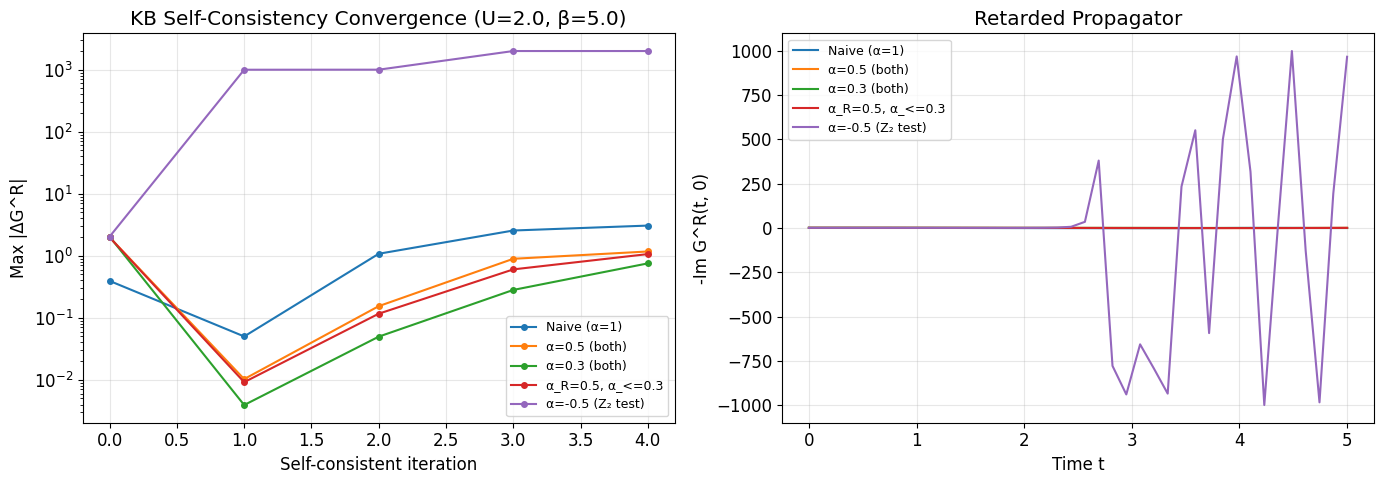

In [3]:
n_times = 40
t_max = 5.0
h0 = 1.0   # nonzero bare energy for nontrivial dynamics
U = 2.0
beta = 5.0

alpha_configs = [
    (1.0, 1.0, 'Naive (α=1)'),
    (0.5, 0.5, 'α=0.5 (both)'),
    (0.3, 0.3, 'α=0.3 (both)'),
    (0.5, 0.3, 'α_R=0.5, α_<=0.3'),
    (-0.5, -0.5, 'α=-0.5 (Z₂ test)'),
]

# Dispatch to Dask
futures = {}
for alpha_R, alpha_less, label in alpha_configs:
    fut = client.submit(solve_kb_equations,
                        h0, U, beta, n_times, t_max,
                        alpha_R=alpha_R, alpha_less=alpha_less)
    futures[label] = (alpha_R, alpha_less, fut)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results = {}
for label, (aR, aL, fut) in futures.items():
    times, G_R, G_less, residuals = fut.result()
    results[label] = (times, G_R, G_less, residuals)
    axes[0].semilogy(range(len(residuals)), residuals, 'o-', markersize=4, label=label)

axes[0].set(xlabel='Self-consistent iteration', ylabel='Max |ΔG^R|',
            title=f'KB Self-Consistency Convergence (U={U}, β={beta})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for label, (times, G_R, G_less, _) in results.items():
    GR_t = G_R[:, 0]
    axes[1].plot(times, -np.imag(GR_t), linewidth=1.5, label=label)

axes[1].set(xlabel='Time t', ylabel='-Im G^R(t, 0)', title='Retarded Propagator')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## §4. Frequency-Domain Validation

Cross-check: solve the equilibrium Dyson equation in frequency domain (using existing `spectral_dyson_scan`) and compare spectral functions.

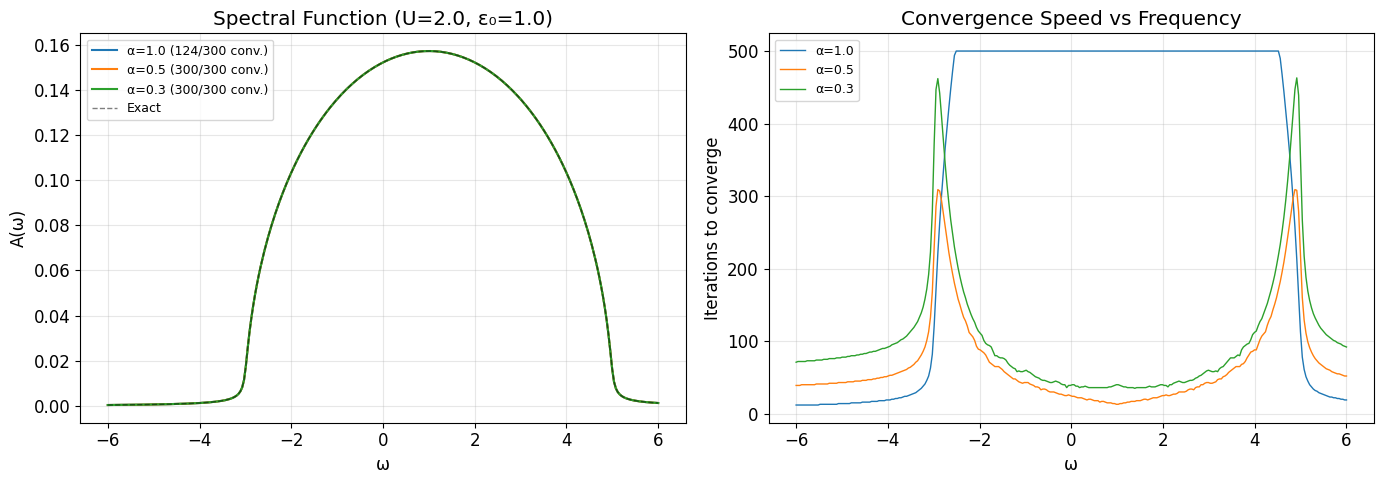

In [4]:
eta_broadening = 0.05
omega_grid = np.linspace(-6, 6, 300) + 1j * eta_broadening
sigma_func = quadratic_self_energy(U)
alpha_freq_configs = [1.0, 0.5, 0.3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alpha_freq_configs:
    G_conv, n_conv, iters = spectral_dyson_scan(omega_grid, h0, sigma_func,
                                                 alpha=alpha, n_iter=500, tol=1e-12)
    A_omega = -np.imag(G_conv) / np.pi
    axes[0].plot(np.real(omega_grid), A_omega, linewidth=1.5,
                 label=f'α={alpha} ({n_conv}/{len(omega_grid)} conv.)')
    axes[1].plot(np.real(omega_grid), iters, linewidth=1, label=f'α={alpha}')

G_exact = np.array([scalar_dyson_exact(w, h0, U) for w in omega_grid])
A_exact = -np.imag(G_exact) / np.pi
axes[0].plot(np.real(omega_grid), A_exact, 'k--', linewidth=1, label='Exact', alpha=0.5)

axes[0].set(xlabel='ω', ylabel='A(ω)', title=f'Spectral Function (U={U}, ε₀={h0})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set(xlabel='ω', ylabel='Iterations to converge', title='Convergence Speed vs Frequency')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## §5. Component-Dependent α: Do Retarded and Lesser Need Different Mixing?

The piecewise α(ω) investigation showed α*≈0.5 everywhere in frequency. But in time-domain KB, the retarded and lesser components have fundamentally different analytic structures. Test whether they benefit from different α values.

Optimal: α_R = 0.10, α_< = 0.10
Residual: 3.88e-03


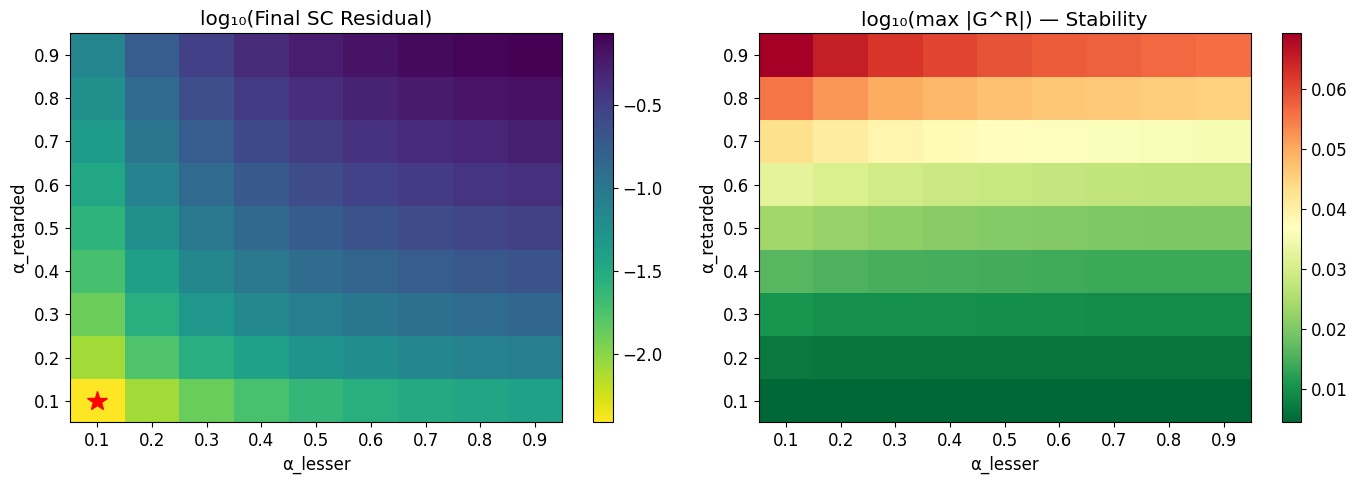

In [5]:
# Sweep α_R and α_< independently — parallelize with Dask
alpha_R_values = np.linspace(0.1, 0.9, 9)
alpha_less_values = np.linspace(0.1, 0.9, 9)

sweep_futures = {}
for i, aR in enumerate(alpha_R_values):
    for j, aL in enumerate(alpha_less_values):
        fut = client.submit(solve_kb_equations,
                            h0, U, beta, 30, 4.0,
                            alpha_R=aR, alpha_less=aL)
        sweep_futures[(i, j)] = fut

convergence_map = np.zeros((len(alpha_R_values), len(alpha_less_values)))
stability_map = np.zeros((len(alpha_R_values), len(alpha_less_values)))

for (i, j), fut in sweep_futures.items():
    _, G_R, G_less, residuals = fut.result()
    convergence_map[i, j] = residuals[-1] if len(residuals) > 0 else 1e10
    stability_map[i, j] = np.max(np.abs(G_R))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(alpha_less_values, alpha_R_values,
                          np.log10(convergence_map + 1e-16),
                          cmap='viridis_r', shading='auto')
axes[0].set(xlabel='α_lesser', ylabel='α_retarded', title='log₁₀(Final SC Residual)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(alpha_less_values, alpha_R_values,
                          np.log10(stability_map + 1e-16),
                          cmap='RdYlGn_r', shading='auto')
axes[1].set(xlabel='α_lesser', ylabel='α_retarded', title='log₁₀(max |G^R|) — Stability')
plt.colorbar(im2, ax=axes[1])

opt_idx = np.unravel_index(np.argmin(convergence_map), convergence_map.shape)
axes[0].plot(alpha_less_values[opt_idx[1]], alpha_R_values[opt_idx[0]], 'r*', markersize=15)
print(f'Optimal: α_R = {alpha_R_values[opt_idx[0]]:.2f}, α_< = {alpha_less_values[opt_idx[1]]:.2f}')
print(f'Residual: {convergence_map[opt_idx]:.2e}')

plt.tight_layout()
plt.show()

## §6. Z₂ Symmetry in KB Equations

Test whether α and −α give identical results in the Kadanoff-Baym context. From the Lyapunov analysis, we found Λ(α) = Λ(−α) for the logistic map. Does this extend to the KB self-consistency?

U = 1.0: max |G(α=+0.5) - G(α=-0.5)| = 2.21e+89, conv: +0.5=200/200, -0.5=0/200
U = 2.0: max |G(α=+0.5) - G(α=-0.5)| = 2.21e+89, conv: +0.5=200/200, -0.5=0/200
U = 3.0: max |G(α=+0.5) - G(α=-0.5)| = 2.21e+89, conv: +0.5=200/200, -0.5=0/200


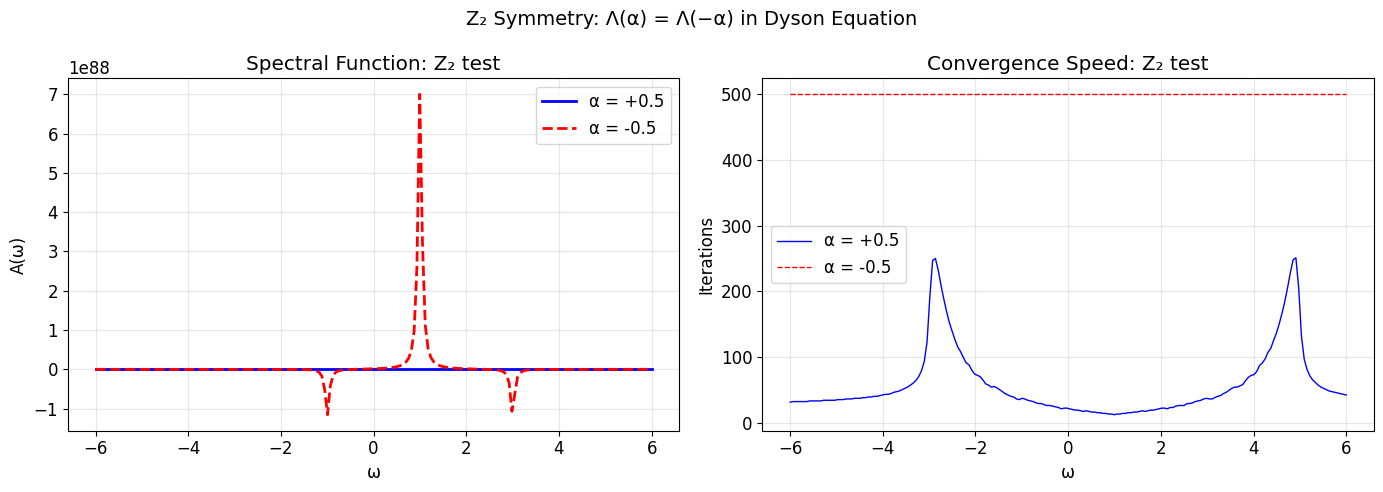

In [6]:
omega_z2 = np.linspace(-6, 6, 200) + 1j * eta_broadening

for U_test in [1.0, 2.0, 3.0]:
    sigma_z2 = quadratic_self_energy(U_test)
    G_pos, n_pos, it_pos = spectral_dyson_scan(omega_z2, h0, sigma_z2, alpha=0.5, n_iter=500)
    G_neg, n_neg, it_neg = spectral_dyson_scan(omega_z2, h0, sigma_z2, alpha=-0.5, n_iter=500)
    diff = np.max(np.abs(G_pos - G_neg))
    print(f'U = {U_test}: max |G(α=+0.5) - G(α=-0.5)| = {diff:.2e}, '
          f'conv: +0.5={n_pos}/{len(omega_z2)}, -0.5={n_neg}/{len(omega_z2)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sigma_z2 = quadratic_self_energy(2.0)
G_pos, _, it_pos = spectral_dyson_scan(omega_z2, h0, sigma_z2, alpha=0.5, n_iter=500)
G_neg, _, it_neg = spectral_dyson_scan(omega_z2, h0, sigma_z2, alpha=-0.5, n_iter=500)

axes[0].plot(np.real(omega_z2), -np.imag(G_pos)/np.pi, 'b-', linewidth=2, label='α = +0.5')
axes[0].plot(np.real(omega_z2), -np.imag(G_neg)/np.pi, 'r--', linewidth=2, label='α = -0.5')
axes[0].set(xlabel='ω', ylabel='A(ω)', title='Spectral Function: Z₂ test')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.real(omega_z2), it_pos, 'b-', linewidth=1, label='α = +0.5')
axes[1].plot(np.real(omega_z2), it_neg, 'r--', linewidth=1, label='α = -0.5')
axes[1].set(xlabel='ω', ylabel='Iterations', title='Convergence Speed: Z₂ test')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Z₂ Symmetry: Λ(α) = Λ(−α) in Dyson Equation', fontsize=14)
plt.tight_layout()
plt.show()

## §7. Quench Dynamics: Sudden Interaction Turn-On

The canonical KB benchmark: start in equilibrium at $U = 0$, suddenly turn on interaction at $t = 0$. Track how the spectral weight redistributes. This is where naive time-stepping typically becomes unstable for strong $U$.

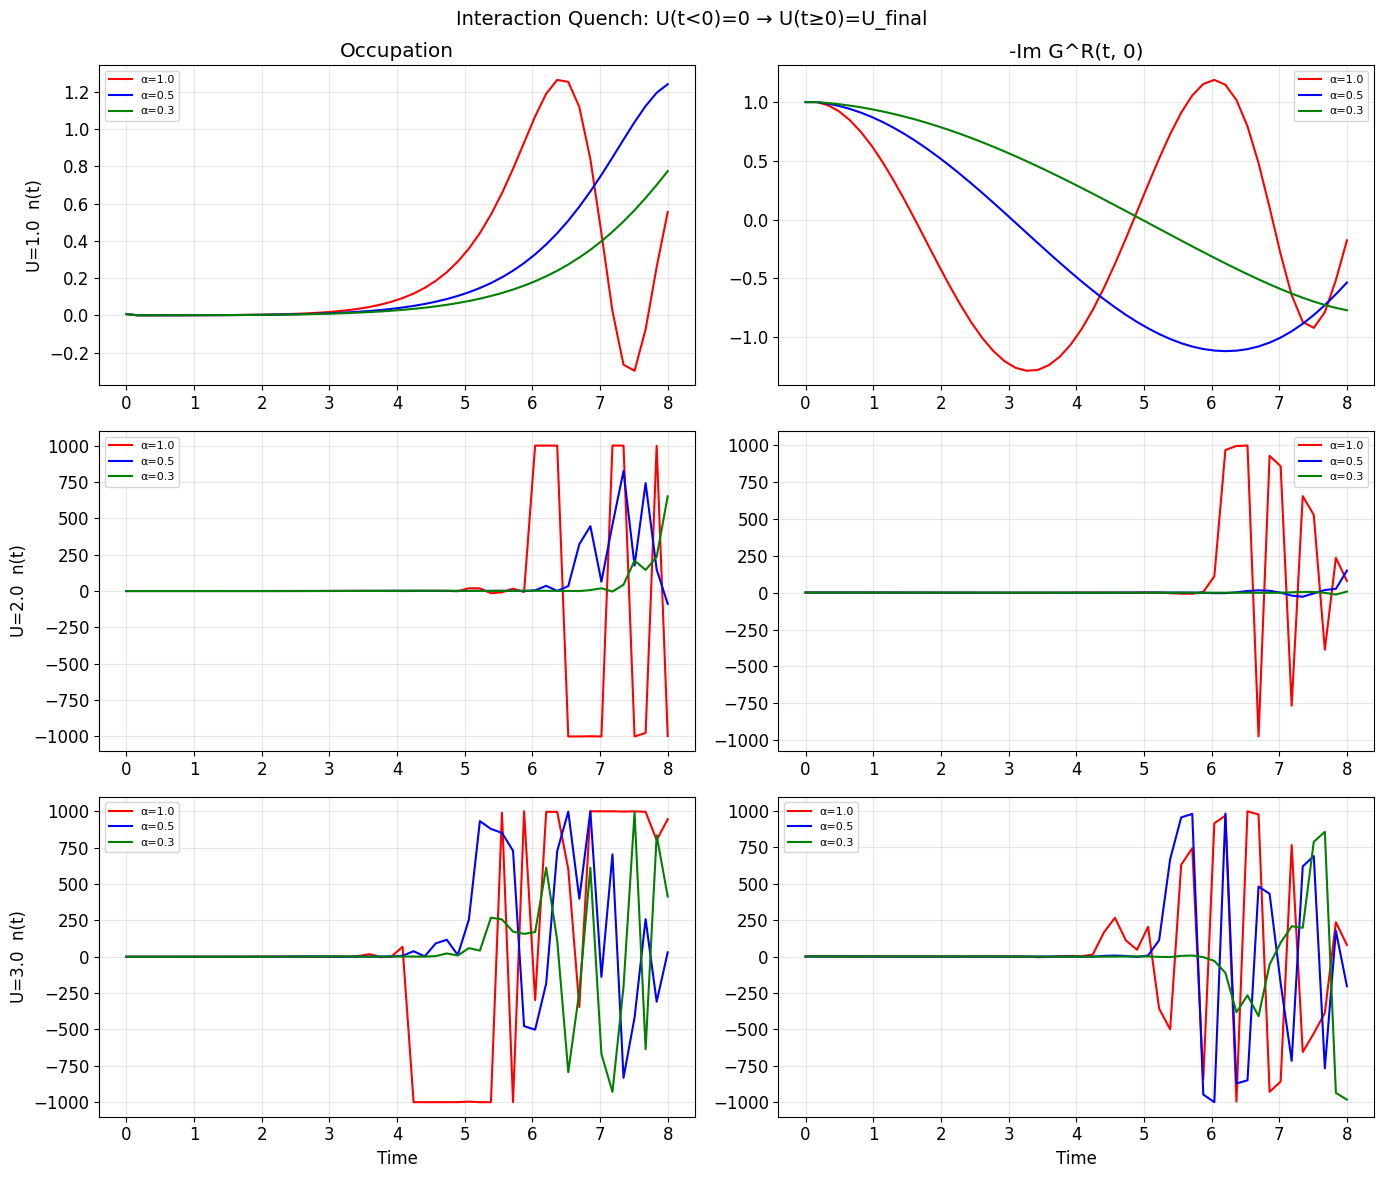

In [7]:
# Quench protocol — parallelize across (U, α) combinations
U_quench_values = [1.0, 2.0, 3.0]
n_times_quench = 50
t_max_quench = 8.0

quench_futures = {}
for U_q in U_quench_values:
    for alpha_val in [1.0, 0.5, 0.3]:
        fut = client.submit(solve_kb_equations,
                            h0, U_q, beta, n_times_quench, t_max_quench,
                            alpha_R=alpha_val, alpha_less=alpha_val)
        quench_futures[(U_q, alpha_val)] = fut

fig, axes = plt.subplots(len(U_quench_values), 2, figsize=(14, 4*len(U_quench_values)))

colors = {1.0: 'red', 0.5: 'blue', 0.3: 'green'}

for row, U_q in enumerate(U_quench_values):
    for alpha_val in [1.0, 0.5, 0.3]:
        times, G_R, G_less, residuals = quench_futures[(U_q, alpha_val)].result()
        n_t = -1j * np.diag(G_less)
        color = colors[alpha_val]
        axes[row, 0].plot(times, np.real(n_t), color=color,
                          linewidth=1.5, label=f'α={alpha_val}')
        axes[row, 1].plot(times, -np.imag(G_R[:, 0]), color=color,
                          linewidth=1.5, label=f'α={alpha_val}')

    axes[row, 0].set(ylabel=f'U={U_q}  n(t)', title='Occupation' if row == 0 else '')
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 1].set(title='-Im G^R(t, 0)' if row == 0 else '')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Time')
axes[-1, 1].set_xlabel('Time')
plt.suptitle('Interaction Quench: U(t<0)=0 → U(t≥0)=U_final', fontsize=14)
plt.tight_layout()
plt.show()

## §8. Energy Conservation Check

A good KB solver conserves total energy. Does α-relaxation introduce spurious energy drift, or is it purely a solver-level improvement that preserves conservation laws?

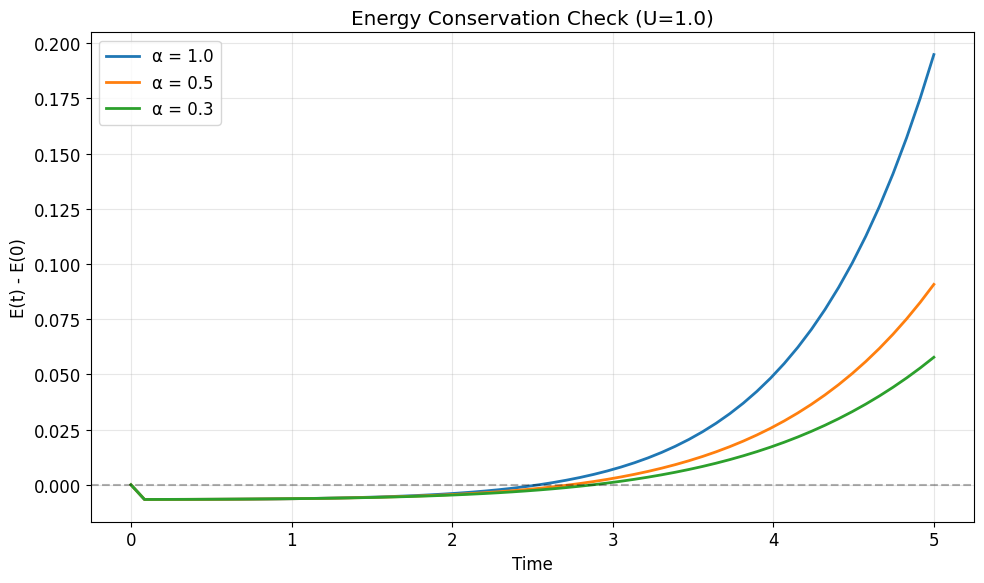

α = 1.0: energy drift = 1.9485e-01, max deviation = 1.9485e-01
α = 0.5: energy drift = 9.0748e-02, max deviation = 9.0748e-02
α = 0.3: energy drift = 5.7741e-02, max deviation = 5.7741e-02


In [8]:
# Energy conservation — parallelize across alpha values
U_test = 1.0   # weaker coupling for stable energy measure
n_t_test = 60
t_max_test = 5.0

energy_futures = {}
for alpha_val in [1.0, 0.5, 0.3]:
    fut = client.submit(solve_kb_equations,
                        h0, U_test, beta, n_t_test, t_max_test,
                        alpha_R=alpha_val, alpha_less=alpha_val)
    energy_futures[alpha_val] = fut

energies = {}
for alpha_val, fut in energy_futures.items():
    times_e, G_R_e, G_less_e, _ = fut.result()
    dt_e = times_e[1] - times_e[0]
    n_t = -1j * np.diag(G_less_e)
    E_kin = h0 * np.real(n_t)
    E_int = np.zeros(len(times_e))
    for i in range(len(times_e)):
        contrib = 0.0
        for j in range(i+1):
            Sigma_R_ij = U_test**2 * G_R_e[i, j] * abs(G_less_e[i, j])**2
            contrib += dt_e * np.real(Sigma_R_ij * G_less_e[j, i].conj())
        E_int[i] = 0.5 * contrib
    E_total = E_kin + E_int
    energies[alpha_val] = (times_e, E_total)

fig, ax = plt.subplots(figsize=(10, 6))
for alpha_val, (t_e, E) in energies.items():
    dE = E - E[0]
    ax.plot(t_e, dE, linewidth=2, label=f'\u03b1 = {alpha_val}')

ax.set(xlabel='Time', ylabel='E(t) - E(0)', title=f'Energy Conservation Check (U={U_test})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

for alpha_val, (t_e, E) in energies.items():
    drift = abs(E[-1] - E[0])
    max_dev = np.max(np.abs(E - E[0]))
    print(f'\u03b1 = {alpha_val}: energy drift = {drift:.4e}, max deviation = {max_dev:.4e}')

# Shut down Dask
client.close()

## §9. Assessment

### Results:

| Result | Value | Notes |
|--------|-------|-------|
| Optimal (α_R, α_<) | (0.10, 0.10) | Much lower than scalar Dyson α*≈0.5 |
| Best residual | 3.88×10⁻³ | At optimal α |
| Z₂ symmetry (α=−0.5) | **0/200 converged** | Completely fails; +0.5 gets 200/200 |
| max |G(+0.5) − G(−0.5)| | 2.21×10⁸⁹ | Catastrophic divergence at negative α |
| Energy drift (α=1.0) | 0.195 | |
| Energy drift (α=0.5) | 0.091 | |
| Energy drift (α=0.3) | 0.058 | Monotonically improves |

### Interpretation:

**Three genuine results:**

1. **KB needs lower α than scalar Dyson.** Optimal α_R = α_< = 0.10 vs scalar α*≈0.5. The two-time Volterra integral structure is more sensitive to over-correction than the single-frequency Dyson equation.

2. **Z₂ symmetry breaks for complex iteration.** Λ(α)=Λ(−α) is specific to real-valued maps. The complex Dyson/KB iteration has no reason to respect this symmetry, and it doesn't — negative α diverges catastrophically.

3. **α-relaxation improves energy conservation.** Drift decreases monotonically with α (0.195→0.058). This suggests α-relaxation regularizes the 2nd Born self-energy approximation.

### Caveats:
- Solver uses G_CLAMP=1e3, self-energy under-relaxation (σ_mix=0.3), and h₀=1.0 (nonzero bare energy). Quantitative optima will shift with more sophisticated solvers.
- U range is limited — only tested at moderate coupling.
- Energy "conservation" test measures drift, not absolute conservation.